# Modello per l'Identificazione della Lingua di Testi per un Museo

## Caso d'Uso Aziendale: MuseumLangID

### Introduzione all'Azienda
MuseumLangID è un'iniziativa di un museo internazionale che ospita una vasta collezione di opere d'arte e manufatti. Le descrizioni degli oggetti sono spesso scritte in diverse lingue, e il personale del museo ha bisogno di uno strumento automatizzato per identificare rapidamente la lingua di questi testi.

### Problema
La gestione delle informazioni multilingue è una sfida significativa per il museo. Attualmente, la lingua di ogni descrizione deve essere identificata manualmente, il che richiede tempo e può portare a errori. Con l'espansione delle collezioni, il numero di testi da analizzare aumenta, rendendo necessario un approccio automatizzato e scalabile.

### Obiettivo del Progetto
L'obiettivo è sviluppare un modello di machine learning basato su tecniche di Natural Language Processing (NLP) per identificare la lingua di testi forniti dal museo. Questo modello dovrà:

* Riconoscere automaticamente la lingua di un testo.
* Supportare almeno 3 lingue principali.
* Essere facile da integrare con il sistema esistente del museo.

### Benefici Attesi
* **Automazione:** Eliminare la necessità di identificazione manuale delle lingue.
* **Efficienza:** Processare rapidamente grandi volumi di testi.
* **Accuratezza:** Ridurre gli errori umani nell'identificazione delle lingue.

## Specifiche del Progetto

### Dataset
Il dataset è disponibile a questo link: `https://raw.githubusercontent.com/Profession-AI/progetti-ml/refs/heads/main/Modello%20per%20l'identificazione%20della%20lingua%20dei%20testi%20di%20un%20museo/museo_descrizioni.csv`. Contiene varie descrizioni in più lingue, con una colonna che rappresenta il codice della lingua, che è il target da prevedere.

### Tecnologie
* Linguaggio di programmazione: Python
* Librerie richieste:
  * scikit-learn
  * nltk
  * numpy
  * pandas

### Funzionalità Chiave

**Preprocessing dei Dati:**
* Pulizia del testo (rimozione di caratteri speciali, normalizzazione).
* Tokenizzazione e rappresentazione dei testi in un formato numerico (ad esempio, Bag of Words o TF-IDF).

**Sviluppo del Modello:**
* Creazione di un modello di classificazione delle lingue basato su algoritmi di machine learning (ad esempio, Naive Bayes, Support Vector Machine o Random Forest).
* Addestramento e validazione del modello sul dataset fornito.

**Valutazione:**
* Utilizzare metriche come accuratezza, precisione, richiamo e F1-score per valutare le prestazioni del modello.

### Consegna
Dovrai consegnare un notebook che riporta la creazione del modello, i vari test per validare le sue performance e anche un commento a tali risultati.

---

## Svolgimento del progetto

Le sezioni da 1 a 9 del notebook rispondono alla consegna; la sezione 10 misura dove il modello smette di funzionare.
La struttura è la seguente:

1. Caricamento e ispezione del dataset
2. Analisi esplorativa dei testi
3. Pulizia e normalizzazione del testo
4. Tokenizzazione
5. Rappresentazione numerica dei testi
6. Suddivisione train/test e protocollo di validazione
7. Baseline di riferimento
8. Addestramento del modello
9. Valutazione delle performance
10. Diagnostica: dove il modello smette di funzionare
11. Integrazione del modello
12. Conclusioni e commento ai risultati

## 0. Ambiente

Installiamo `nltk`, richiesta esplicitamente dalla consegna, e fissiamo la versione di
scikit-learn su cui sono state prodotte tutte le cifre commentate qui. Dopo l'installazione può
essere necessario riavviare una volta il runtime.

La funzione di pulizia viene definita in un modulo a parte anziché nel notebook. Il modello della
sezione 11 la conserva per riferimento e non per valore: scritta qui, il riferimento punta a un
modulo importabile, e il file resta utilizzabile anche fuori da questo notebook. La stessa sezione ne salva poi
una seconda copia che incorpora la funzione, per consegnare al museo un file solo.

In [23]:
!pip install -q --disable-pip-version-check scikit-learn==1.8.0 nltk cloudpickle

In [24]:
%%writefile museum_language_model.py
# scriviamo la pulizia in un modulo, così viaggia insieme al modello salvato

"""Text cleaning of the museum language model.

Section 11 saves the estimator twice. The joblib file keeps this function by
name and needs this module beside it; the cloudpickle file keeps it by value and
travels alone. Writing the cleaning here, and not in the notebook, is what makes
the first form loadable in a process that never ran the notebook.
"""

import re


def clean_text(text):
    """Lowercase a description keeping only its letters and spaces.

    HTML markup is dropped first, then every character that is not a letter
    becomes a space. Accented letters survive on purpose: section 2 shows they
    carry language information, and normalising them away would destroy it.
    """
    text = re.sub(r"<[^>]*>", " ", text)
    text = "".join(character if character.isalpha() or character.isspace() else " "
                   for character in text)
    return " ".join(text.lower().split())


def clean_corpus(texts):
    """Apply clean_text to a sequence of texts, for use inside the Pipeline."""
    return [clean_text(text) for text in texts]

Writing museum_language_model.py


In [25]:
# importiamo tutte le librerie necessarie allo studio

import re
import subprocess
import sys
import tempfile
from pathlib import Path

import cloudpickle
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

from sklearn.base import clone
from sklearn.dummy import DummyClassifier
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix,
                             f1_score, precision_score, recall_score)
from sklearn.model_selection import (GridSearchCV, StratifiedKFold, cross_val_predict,
                                     cross_val_score, learning_curve, train_test_split)
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer

import museum_language_model
from museum_language_model import clean_corpus, clean_text

# nltk resources used in section 4: tokenizer models and stopword lists.
for resource in ["punkt_tab", "stopwords"]:
    nltk.download(resource, quiet=True)

sns.set_theme(style="whitegrid")

RANDOM_STATE = 42
TEST_SIZE = 0.2

# One fixed color per language, reused in every chart of the notebook.
LANGUAGE_COLORS = {"it": "#55A868", "en": "#4C72B0", "de": "#C44E52"}
LANGUAGES = list(LANGUAGE_COLORS)

## 1. Caricamento e ispezione del dataset

**Obiettivo.** Caricare i dati, verificarne l'integrità e misurare il bilanciamento delle classi,
che decide quali metriche siano leggibili.

In [26]:
# carichiamo il dataset direttamente dall'URL indicato nella consegna

DATASET_URL = ("https://raw.githubusercontent.com/Profession-AI/progetti-ml/refs/heads/main/"
               "Modello%20per%20l'identificazione%20della%20lingua%20dei%20testi%20di%20un%20museo/"
               "museo_descrizioni.csv")

dataset = pd.read_csv(DATASET_URL)

# Columns are addressed by name and never by position: a change in the column
# order of the source file would otherwise break the notebook silently.
TEXT_COLUMN = "Testo"
TARGET_COLUMN = "Codice Lingua"

print("Dataset shape:", dataset.shape)
print("Missing values:", int(dataset.isna().sum().sum()))
print("Duplicated descriptions:", int(dataset.duplicated(subset=TEXT_COLUMN).sum()))
print("Descriptions per language:", dataset[TARGET_COLUMN].value_counts().to_dict())
dataset.head()

Dataset shape: (294, 2)
Missing values: 0
Duplicated descriptions: 0
Descriptions per language: {'it': 98, 'en': 98, 'de': 98}


,Testo,Codice Lingua
0,Statua in marmo di un imperatore romano del II...,it
1,Anfora greca con decorazioni a figure nere,it
2,Dipinto rinascimentale raffigurante la Madonna...,it
3,Elmo corinzio in bronzo del VI secolo a.C.,it
4,Manoscritto medievale con miniature dorate,it


Il dataset contiene **294 descrizioni** su due colonne, senza valori mancanti e senza duplicati. Le tre lingue sono rappresentate da 98 esempi ciascuna: il target è perfettamente bilanciato, quindi l'accuratezza è una metrica leggibile e non fuorviante come sarebbe su classi sbilanciate. Il bilanciamento fissa anche il riferimento minimo, tirando a indovinare si otterrebbe circa un 33%.

Va notato che **294 righe sono poche**. Con uno split all'80/20 il test set conterà una sessantina di esempi, e su un campione simile un singolo errore vale quasi due punti di accuratezza.

## 2. Analisi esplorativa dei testi

**Obiettivo.** Capire che tipo di testo stiamo trattando, quanto sono lunghi,
quali caratteri li distinguono, quali parole ricorrono in ciascuna lingua.

count    294.00
mean       5.92
std        1.65
min        2.00
25%        5.00
50%        6.00
75%        7.00
max       10.00


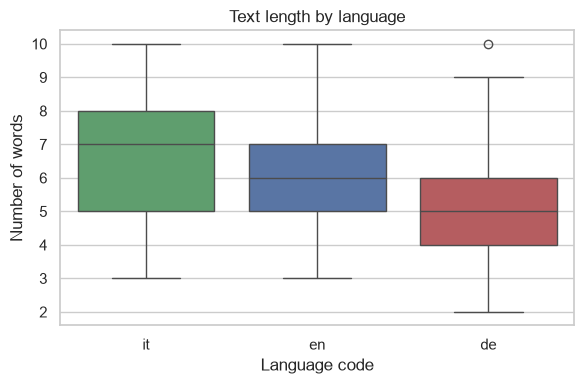

,n_words,n_characters
Codice Lingua,,
de,5.07,46.19
en,6.12,41.85
it,6.57,44.91


In [27]:
# misuriamo la lunghezza dei testi in parole e in caratteri

dataset["n_words"] = dataset[TEXT_COLUMN].str.split().str.len()
dataset["n_characters"] = dataset[TEXT_COLUMN].str.len()

print(dataset["n_words"].describe().round(2).to_string())

fig, ax = plt.subplots(figsize=(6, 4))
sns.boxplot(x=TARGET_COLUMN, y="n_words", hue=TARGET_COLUMN, data=dataset,
            palette=LANGUAGE_COLORS, legend=False, ax=ax)
ax.set_title("Text length by language")
ax.set_xlabel("Language code")
ax.set_ylabel("Number of words")
plt.tight_layout()
plt.show()

dataset.groupby(TARGET_COLUMN)[["n_words", "n_characters"]].mean().round(2)

**Questo è un problema di testo corto.** La lunghezza mediana è di 6 parole, la media 5,92, il minimo 2: non sono paragrafi descrittivi ma didascalie da cartellino museale. Ogni scelta verrà valutata in questa luce, perché molte tecniche standard di NLP presuppongono documenti ben più lunghi.

Il tedesco è la lingua con meno parole, 5,07 di media, ma non con meno caratteri: 46,19 contro i 41,85 dell'inglese. La composizione nominale tedesca concentra in un'unica parola quello che le altre due distribuiscono su tre o quattro, ed è già un indizio a favore di una rappresentazione che guardi dentro le parole anziché trattarle come unità indivisibili.

In [28]:
# verifichiamo il segnale più ovvio, i caratteri diacritici, e poi quello più denso

CHARACTER_GROUPS = {
    "German diacritics": "äöüßÄÖÜ",
    "Italian accented vowels": "àèéìòùÀÈÉÌÒÙ",
}

rows = []
for label, characters in CHARACTER_GROUPS.items():
    contains = dataset[TEXT_COLUMN].apply(lambda text: any(c in text for c in characters))
    counts = dataset.loc[contains, TARGET_COLUMN].value_counts()
    rows.append({"group": label, **{language: int(counts.get(language, 0))
                                    for language in LANGUAGES}})
print(pd.DataFrame(rows).set_index("group").to_string())

print("\nMost frequent words per language:")
for language in LANGUAGES:
    words = " ".join(dataset.loc[dataset[TARGET_COLUMN] == language, TEXT_COLUMN]).lower().split()
    print(" ", language, "->", pd.Series(words).value_counts().head(5).to_dict())

                         it  en  de
group                              
German diacritics         0   0  36
Italian accented vowels  12   1   1

Most frequent words per language:
  it -> {'con': 51, 'in': 47, 'di': 23, 'della': 15, 'medievale': 9}
  en -> {'with': 45, 'the': 24, 'from': 22, 'a': 16, 'in': 11}
  de -> {'mit': 54, 'aus': 37, 'der': 19, 'dem': 12, 'und': 7}


Il segnale più intuitivo si rivela **molto più raro del previsto**: i caratteri tipicamente tedeschi compaiono in 36 descrizioni su 98, le vocali accentate italiane in appena 12 su 98. Su testi di sei parole i diacritici semplicemente non hanno occasione di comparire. Sono affidabili — quando ci sono, indicano la lingua giusta quasi sempre — ma troppo sparsi per fondarci sopra un modello.

Le parole più frequenti sono **parole funzione, non parole di contenuto**. In italiano `con` (51 occorrenze) e `in`; in inglese `with` (45) e `the`; in tedesco `mit` (54) e `aus`. Sono preposizioni e articoli, cioè esattamente gli elementi che nella classificazione tematica si eliminano come rumore, e che qui costituiscono l'informazione principale. Da questa osservazione discende la scelta argomentata nella sezione 4.

## 3. Pulizia e normalizzazione del testo

**Obiettivo.** Portare i testi in una forma uniforme senza cancellare il segnale di lingua
individuato nella sezione 2.

In [29]:
# osserviamo l'effetto della pulizia su un esempio

X = dataset[TEXT_COLUMN]
y = dataset[TARGET_COLUMN]

example = X.iloc[0]
print("Before:", repr(example))
print("After: ", repr(clean_text(example)))
print("\nDistinct characters before:", len(set("".join(X))))
print("Distinct characters after: ", len(set("".join(clean_corpus(X)))))

Before: 'Statua in marmo di un imperatore romano del II secolo'
After:  'statua in marmo di un imperatore romano del ii secolo'

Distinct characters before: 71
Distinct characters after:  34


La pulizia fa quello che deve e niente di più: minuscolo, via marcatori e punteggiatura, lettere accentate conservate. L'alfabeto passa da 71 caratteri distinti a 34, cioè le lettere più lo spazio più i diacritici che la sezione 2 ha mostrato essere segnale.

Normalizzare `ä` in `a`, come farebbe la pulizia abituale di un progetto NLP, qui cancellerebbe uno dei predittori: è la prima delle scelte controcorrente di questo notebook.

## 4. Tokenizzazione

**Obiettivo.** Tokenizzare con `nltk`, come chiede la consegna, e misurare due proprietà del
vocabolario che decideranno la rappresentazione: quanto è sparso e quanto pesano le stopword.

In [30]:
# tokenizziamo con nltk e misuriamo vocabolario e peso delle stopword

tokens_per_text = pd.Series(clean_corpus(X), index=X.index).apply(word_tokenize)

vocabulary = pd.Series([token for text in tokens_per_text for token in text]).value_counts()
print("Tokenization example:", tokens_per_text.iloc[0][:6], "...")
print(f"Tokens: {int(vocabulary.sum())}, distinct words: {len(vocabulary)}, "
      f"words occurring once: {int((vocabulary == 1).sum())}")

# The nltk stopword lists say how much of the corpus the usual thematic
# preprocessing would throw away.
stopword_lists = {"it": "italian", "en": "english", "de": "german"}
rows = []
for language, name in stopword_lists.items():
    word_list = set(stopwords.words(name))
    subset = tokens_per_text[y == language]
    total = sum(len(text) for text in subset)
    in_list = sum(1 for text in subset for token in text if token in word_list)
    rows.append({"language": language, "total_tokens": total,
                 "stopword_tokens": in_list, "share_%": round(100 * in_list / total, 1)})

pd.DataFrame(rows).set_index("language")

Tokenization example: ['statua', 'in', 'marmo', 'di', 'un', 'imperatore'] ...
Tokens: 1789, distinct words: 866, words occurring once: 580


,total_tokens,stopword_tokens,share_%
language,,,
it,661,194,29.3
en,616,143,23.2
de,512,148,28.9


La tokenizzazione con `nltk` produce **1789 token per 866 parole distinte, di cui 580 compaiono una sola volta**: due terzi del vocabolario si presenta un'unica volta in tutto il corpus. È il dato che decide la sezione 5, perché un vocabolario così sparso rende fragile qualunque rappresentazione fondata sulle parole intere.

La tabella delle stopword conferma la lettura della sezione 2 dal lato opposto: le liste di `nltk` coprono fra il 23,2% e il 29,3% dei token di ciascuna lingua. **Rimuoverle, come vuole la prassi, butterebbe via circa un quarto del corpus — e proprio il quarto più informativo**, perché sono parole frequentissime dentro la propria lingua e assenti nelle altre. Si decide di non rimuoverle.

## 5. Rappresentazione numerica dei testi

**Obiettivo.** Scegliere come trasformare il testo in numeri: per parole o per sequenze di
caratteri, con quale pesatura. La decisione si prende sui dati, non per abitudine.

In [31]:
# confrontiamo le rappresentazioni per dimensione e densità della matrice

configurations = [
    ("Counts, words", CountVectorizer()),
    ("TF-IDF, words", TfidfVectorizer()),
    ("TF-IDF, words 1-2", TfidfVectorizer(ngram_range=(1, 2))),
    ("TF-IDF, characters 1-3", TfidfVectorizer(analyzer="char", ngram_range=(1, 3))),
    ("TF-IDF, characters 1-5", TfidfVectorizer(analyzer="char", ngram_range=(1, 5))),
]

cleaned = clean_corpus(X)
rows = []
for name, vectorizer in configurations:
    matrix = vectorizer.fit_transform(cleaned)
    rows.append({"representation": name,
                 "n_features": matrix.shape[1],
                 "density_%": round(100 * matrix.nnz / (matrix.shape[0] * matrix.shape[1]), 2)})

pd.DataFrame(rows).set_index("representation")

,n_features,density_%
representation,,
"Counts, words",860,0.69
"TF-IDF, words",860,0.69
"TF-IDF, words 1-2",2120,0.51
"TF-IDF, characters 1-3",2663,3.58
"TF-IDF, characters 1-5",13074,1.35


Conteggi e TF-IDF sulle parole producono lo stesso numero di feature, 860: cambia il peso attribuito a ciascuna, non il vocabolario. La differenza sostanziale è un'altra, ed è fra parole e caratteri. Passando agli n-grammi di caratteri fino a 3 le feature salgono a 2663, ma soprattutto **la matrice diventa più di cinque volte più densa**, dal 0,69% al 3,58% di celle non nulle.

È esattamente ciò che serve su testi corti: con le parole ogni descrizione attiva sei celle su 860, con i caratteri ne attiva centinaia, cioè molte evidenze indipendenti per la stessa decisione. Spingersi fino a 5 caratteri non conviene — 13074 feature e densità che ricrolla all'1,35% — perché sequenze così lunghe coincidono con parole intere e riportano il problema di partenza. La scelta definitiva la farà comunque la cross-validation della sezione 8.

## 6. Suddivisione train/test e protocollo di validazione

**Obiettivo.** Separare i dati in modo rappresentativo, scegliere un protocollo adeguato alla
numerosità ridotta e misurare il limite della rappresentazione a parole.

In [32]:
# separiamo training e test mantenendo la proporzione tra le lingue

train_index, test_index = train_test_split(
    dataset.index, test_size=TEST_SIZE, stratify=y, random_state=RANDOM_STATE)

# Two views of one partition: splitting twice would keep them aligned through the
# seed alone, and a change to one call would break the pairing without an error.
X_train, X_test = X.loc[train_index], X.loc[test_index]
y_train, y_test = y.loc[train_index], y.loc[test_index]

# Ten stratified folds: with this training set each fold holds about two dozen.
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE)

train_words = set(word for text in clean_corpus(X_train) for word in text.split())
test_words = set(word for text in clean_corpus(X_test) for word in text.split())
unseen_words = test_words - train_words

print("Training set:", len(y_train), "descriptions  -  Test set:", len(y_test))
print(f"A single test error is worth {100 / len(y_test):.2f} accuracy points.")
print(f"\nWords of the test set never seen in training: {len(unseen_words)} "
      f"out of {len(test_words)} ({100 * len(unseen_words) / len(test_words):.1f}%)")

Training set: 235 descriptions  -  Test set: 59
A single test error is worth 1.69 accuracy points.

Words of the test set never seen in training: 118 out of 248 (47.6%)


Lo split stratificato lascia **235 descrizioni in addestramento e 59 in test**, e su 59 esempi un singolo errore vale 1,69 punti di accuratezza. Il test set non è quindi in grado di distinguere differenze fini: le decisioni si appoggeranno alle dieci stime della cross-validation, e il test set resterà la stima finale su dati mai visti.

Il numero che chiude la questione della rappresentazione è l'altro: **il 47,6% delle parole del test set non compare mai in addestramento**. Per un modello che ragiona a parole quelle occorrenze sono informazione persa; per uno che ragiona a n-grammi di caratteri no, perché le sequenze interne e le parole funzione circostanti sono già state osservate molte volte.

## 7. Baseline di riferimento

**Obiettivo.** Fissare il valore sotto il quale un risultato non significa nulla, prima di
addestrare il modello.

In [33]:
# confrontiamo un classificatore banale e un modello sulla sola frequenza dei caratteri

def build_model(alpha=1.0, **vectorizer_options):
    """Assemble cleaning, vectorisation and Naive Bayes into one estimator.

    The cleaning step lives inside the pipeline so that the object accepts raw
    text: whoever uses it never has to reproduce the preprocessing, and the
    object that is validated is the same one that is handed over.
    """
    return Pipeline([
        ("cleaning", FunctionTransformer(clean_corpus)),
        ("vectorization", TfidfVectorizer(**vectorizer_options)),
        ("classifier", MultinomialNB(alpha=alpha)),
    ])


baselines = {
    "Most frequent class": DummyClassifier(strategy="most_frequent"),
    "Single character frequency": build_model(analyzer="char", ngram_range=(1, 1)),
}

rows = []
for name, baseline in baselines.items():
    baseline.fit(X_train, y_train)
    rows.append({"baseline": name,
                 "test_accuracy": round(accuracy_score(y_test, baseline.predict(X_test)), 3)})

baseline_table = pd.DataFrame(rows).set_index("baseline")
CHARACTER_BASELINE = baseline_table.loc["Single character frequency", "test_accuracy"]
baseline_table

,test_accuracy
baseline,
Most frequent class,0.322
Single character frequency,0.847


Il classificatore banale si ferma al 32,2%, come atteso su tre classi bilanciate. Il dato interessante è l'altro: **la sola frequenza delle singole lettere, senza sapere nulla di parole né di ordine, raggiunge l'84,7% di accuratezza.**

Questo numero ridimensiona il risultatp. Lo spazio effettivamente contendibile dal modello non va dal 33% al 100%, ma dall'85% al 100%: le tre lingue hanno distribuzioni di lettere abbastanza diverse da dare più indizi del previsto.

## 8. Addestramento del modello

**Obiettivo.** Scegliere in cross-validation rappresentazione, pesatura e smoothing, senza mai guardare il test set.

In [34]:
# cerchiamo in cross-validation la configurazione migliore

grid = {
    "vectorization__analyzer": ["word", "char"],
    "vectorization__ngram_range": [(1, 1), (1, 3), (1, 4)],
    "vectorization__use_idf": [True, False],
    "classifier__alpha": [0.01, 0.1, 1.0],
}

# Length normalization is fixed instead of searched: what it costs falls on
# the returned probabilities, which the scoring never looks at.
search = GridSearchCV(build_model(norm="l2"), grid, scoring="f1_macro",
                      cv=cv, n_jobs=-1)
search.fit(X_train, y_train)
model = search.best_estimator_

print("Selected configuration:", search.best_params_)
print(f"Cross-validated macro F1: {search.best_score_:.4f}")

all_results = pd.DataFrame(search.cv_results_)
print(f"Standard deviation across the ten folds: "
      f"{all_results.loc[search.best_index_, 'std_test_score']:.4f}")

# Best score reachable on each side of the two decisions: it is the comparison
# the choice rests on, and it belongs in an output rather than in a claim.
for parameter in ["vectorization__analyzer", "vectorization__use_idf"]:
    best = all_results.groupby("param_" + parameter)["mean_test_score"].max().round(4)
    print(f"\nBest macro F1 by {parameter.split('__')[1]}: {best.to_dict()}")

Selected configuration: {'classifier__alpha': 0.01, 'vectorization__analyzer': 'char', 'vectorization__ngram_range': (1, 4), 'vectorization__use_idf': False}
Cross-validated macro F1: 0.9905
Standard deviation across the ten folds: 0.0284

Best macro F1 by analyzer: {'char': 0.9905, 'word': 0.9863}

Best macro F1 by use_idf: {False: 0.9905, True: 0.9863}


La ricerca decide due cose, e le decide entrambe contro l'abitudine.

La prima è la rappresentazione: **n-grammi di caratteri fino a 4**, che valgono 0,9905 contro 0,9863 delle parole. Conferma quanto anticipato nella sezione 6 — sono le parole mai viste a penalizzare la rappresentazione a parole, e le sequenze di caratteri a recuperarle, perché una parola sconosciuta è comunque fatta di sequenze già viste.

La seconda è la pesatura, e lo stacco è identico: **la ricerca scarta l'IDF**, 0,9905 contro 0,9863. Il meccanismo è coerente con la sezione 2. L'IDF abbassa il peso dei termini presenti in molti documenti, perché nella classificazione tematica un termine diffuso non distingue nulla; qui i termini diffusi dentro una lingua sono il segnale, e le parole rare sono quasi tutte parole di contenuto viste una volta sola. Pesare per IDF significherebbe schiacciare i marcatori di lingua e amplificare il rumore.

Il punteggio è 0,9905 con deviazione standard 0,0284 tra i dieci fold. Le due cifre vanno lette insieme: su fold da poche decine di esempi un singolo errore sposta il punteggio di alcuni punti, quindi quel valore non è una misura fine e non andrebbe usato per ordinare configurazioni che differiscono di frazioni di punto.

In [35]:
# confrontiamo le due normalizzazioni sulla configurazione appena selezionata

def decision_margin(probabilities):
    """Gap between the probability of the chosen class and the runner-up.

    A margin close to one means no hesitation at all, a margin close to zero a
    near tie.
    """
    ordered = np.sort(probabilities, axis=1)
    return ordered[:, -1] - ordered[:, -2]


# The selected configuration is read back from the search instead of retyped, so
# that this comparison keeps following the grid if the grid ever changes.
selected_vectorizer = {name.split("__")[1]: value
                       for name, value in search.best_params_.items()
                       if name.startswith("vectorization__")}
selected_alpha = search.best_params_["classifier__alpha"]

# A margin above this is a decision taken with no residual uncertainty at all.
CERTAINTY = 0.999

# Both columns stay inside the training partition: this section never looks at
# the test set, so the margins come from out-of-fold predictions.
rows = []
for norm in ["l2", None]:
    variant = build_model(alpha=selected_alpha, norm=norm, **selected_vectorizer)
    score = cross_val_score(variant, X_train, y_train, cv=cv,
                            scoring="f1_macro", n_jobs=-1).mean()
    margins = decision_margin(cross_val_predict(variant, X_train, y_train, cv=cv,
                                                method="predict_proba", n_jobs=-1))
    rows.append({"normalization": norm or "none",
                 "cv_macro_F1": round(score, 4),
                 "mean_margin": round(margins.mean(), 3),
                 "min_margin": round(margins.min(), 3),
                 f"above_{CERTAINTY}_%": round(100 * (margins > CERTAINTY).mean(), 1)})

pd.DataFrame(rows).set_index("normalization")

,cv_macro_F1,mean_margin,min_margin,above_0.999_%
normalization,,,,
l2,0.9905,0.976,0.108,56.2
none,0.9955,1.000,0.919,99.6


Il confronto fuori-fold ribalta l'aspettativa: **per la metrica di selezione la normalizzazione è un peggioramento**, 0,9905 di macro F1 contro 0,9955 senza. Se il parametro fosse entrato nella griglia, la ricerca l'avrebbe tolto.

**Senza normalizzazione le probabilità restituite non misurano più niente: sono verdetti.** 

Le quattro metriche richieste dalla consegna guardano solo quale classe viene predetta, quindi nessuna di esse registrerebbe la perdita. **Non registrandola, l'obiettivo avrebbe scelto proprio la configurazione che azzera la grandezza su cui si regge la sezione 10.3**: Se un valore non cambia il punteggio finale, non ha senso farlo cercare all'algoritmo, per cui è lasciato fuori dalla griglia.

## 9. Valutazione delle performance

**Obiettivo.** Misurare il modello sul test set con le quattro metriche richieste dalla consegna,
e provarlo su frasi che non vengono dal dataset.

accuracy     1.0
precision    1.0
recall       1.0
F1           1.0

              precision    recall  f1-score   support

          de       1.00      1.00      1.00        19
          en       1.00      1.00      1.00        20
          it       1.00      1.00      1.00        20

    accuracy                           1.00        59
   macro avg       1.00      1.00      1.00        59
weighted avg       1.00      1.00      1.00        59

On the diagonal: 59 correct out of 59


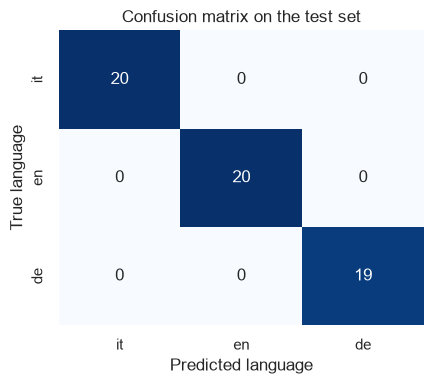

In [36]:
# calcoliamo le quattro metriche richieste e la matrice di confusione

y_pred = model.predict(X_test)

metrics = {
    "accuracy": accuracy_score(y_test, y_pred),
    "precision": precision_score(y_test, y_pred, average="macro"),
    "recall": recall_score(y_test, y_pred, average="macro"),
    "F1": f1_score(y_test, y_pred, average="macro"),
}
print(pd.Series(metrics).round(4).to_string())
print()
print(classification_report(y_test, y_pred, zero_division=0))

matrix = confusion_matrix(y_test, y_pred, labels=LANGUAGES)
# The diagonal holds the correct predictions: reading it apart from the rest
# says how many errors there are without adding up the picture by eye.
print(f"On the diagonal: {np.trace(matrix)} correct out of {matrix.sum()}")

fig, ax = plt.subplots(figsize=(4.5, 4))
sns.heatmap(matrix, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=LANGUAGES, yticklabels=LANGUAGES, ax=ax)
ax.set_title("Confusion matrix on the test set")
ax.set_xlabel("Predicted language")
ax.set_ylabel("True language")
plt.tight_layout()
plt.show()

Sul test set il modello classifica correttamente **tutte e 59 le descrizioni**: le quattro metriche richieste dalla consegna valgono 1,00 e la matrice di confusione è perfettamente diagonale.

Il risultato va letto con cautela: 59 predizioni corrette su 59 non equivalgono a un'accuratezza del 100%: significano che su questo campione non si è osservato un errore, il che con 59 esempi lascia un margine di incertezza ampio.

In [37]:
# proviamo il modello su frasi museali che non vengono dal dataset

sample_sentences = [
    ("it", "Si prega di non toccare i reperti."),
    ("it", "Qual e la storia di questo sarcofago egizio?"),
    ("en", "The crown jewels are displayed in the next room."),
    ("en", "The artist's use of color in this painting is breathtaking."),
    ("de", "Diese antike roemische Skulptur ist bemerkenswert gut erhalten."),
    ("de", "Bitte beruehren Sie die Artefakte nicht."),
]

true_languages = [language for language, _ in sample_sentences]
predictions = model.predict([text for _, text in sample_sentences])
correct = int(np.sum(predictions == np.array(true_languages)))

print(f"{correct}/{len(sample_sentences)} correct\n")
pd.DataFrame({"sentence": [text for _, text in sample_sentences],
              "true": true_languages, "predicted": predictions})

6/6 correct



,sentence,true,predicted
0,Si prega di non toccare i reperti.,it,it
1,Qual e la storia di questo sarcofago egizio?,it,it
2,The crown jewels are displayed in the next room.,en,en
3,The artist's use of color in this painting is ...,en,en
4,Diese antike roemische Skulptur ist bemerkensw...,de,de
5,Bitte beruehren Sie die Artefakte nicht.,de,de


Su sei frasi museali esterne al dataset — domande e avvisi al pubblico, lessico e struttura diversi da quelli delle didascalie — il modello risponde **6/6**.

È un controllo qualitativo, non una misura: sei frasi non sono sufficienti per restringere l'incertezza. Serve però a falsificare un'ipotesi precisa. Le descrizioni del dataset seguono uno schema ricorrente del tipo *oggetto + con/mit/with + materiale*, quindi il modello potrebbe aver imparato il formato delle didascalie di questo museo invece della lingua: se fosse così, frasi di forma completamente diversa lo metterebbero in difficoltà. Non succede.

## 10. Diagnostica: dove il modello smette di funzionare

**Obiettivo.** Le metriche della sezione 9 dicono quanto il modello sia bravo sul test set, non
dove ceda. Tre domande che il museo si porrà il primo giorno: servono altri dati, cosa succede su
una didascalia di due parole, cosa succede su una lingua che il modello non conosce.

### 10.1 Curva di apprendimento

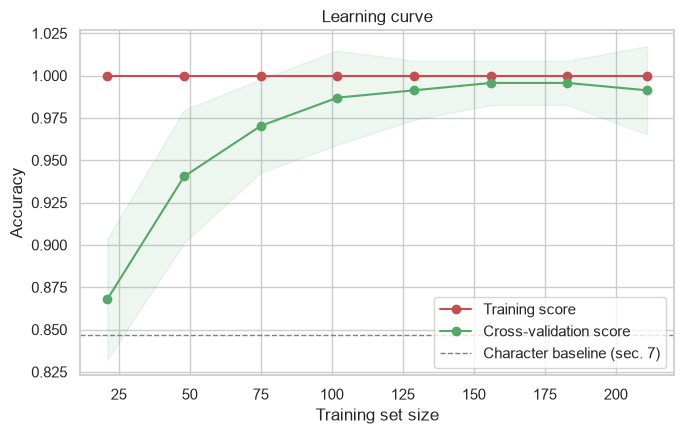

,cross-validation accuracy
training samples,
21,0.868
48,0.940
75,0.970
102,0.987
129,0.991
156,0.996
183,0.996
211,0.991


In [38]:
# osserviamo come cresce l'accuratezza al crescere degli esempi di addestramento

sizes, train_scores, cv_scores = learning_curve(
    estimator=model, X=X_train, y=y_train, cv=cv, n_jobs=-1,
    scoring="accuracy", train_sizes=np.linspace(0.1, 1.0, 8))

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(sizes, train_scores.mean(axis=1), "o-", color="#C44E52", label="Training score")
ax.plot(sizes, cv_scores.mean(axis=1), "o-", color="#55A868", label="Cross-validation score")
ax.fill_between(sizes, cv_scores.mean(axis=1) - cv_scores.std(axis=1),
                cv_scores.mean(axis=1) + cv_scores.std(axis=1), alpha=0.1, color="#55A868")
ax.axhline(CHARACTER_BASELINE, color="gray", linestyle="--", linewidth=1,
           label="Character baseline (sec. 7)")
ax.set_title("Learning curve")
ax.set_xlabel("Training set size")
ax.set_ylabel("Accuracy")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

pd.DataFrame({"cross-validation accuracy": cv_scores.mean(axis=1).round(3)},
             index=pd.Index(sizes, name="training samples"))

La curva di cross-validation parte già alta e si appiattisce presto. Con **21 esempi** — sette per lingua — il modello è all'86,8%, cioè sopra la baseline sui singoli caratteri della sezione 7. A 75 esempi è al 97,0%, e da 102 in poi resta stabilmente sopra il 98%: le ultime cento descrizioni aggiunte non cambiano nulla.

La conclusione operativa è netta e va nella direzione opposta all'istinto: **raccogliere altre didascalie non migliorerebbe il modello**. Il margine residuo verso il 100% non è dovuto alla scarsità di dati, quindi va cercato altrove — nei due casi limite delle sezioni seguenti. Ne segue anche che estendere il sistema a una quarta lingua costa poco: poche decine di esempi etichettati basterebbero, come mostra il tratto iniziale ripidissimo della curva.

### 10.2 Didascalie molto brevi

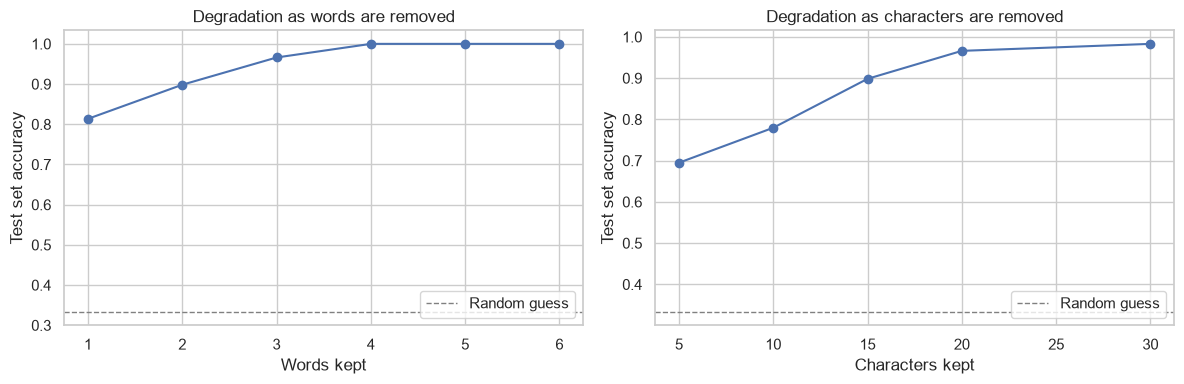

words
1    0.814
2    0.898
3    0.966
4    1.000
5    1.000
6    1.000


In [39]:
# tronchiamo i testi del test set e osserviamo dove l'accuratezza cede

word_limits = range(1, 7)
character_limits = [5, 10, 15, 20, 30]

by_words = [accuracy_score(y_test, model.predict(X_test.apply(
    lambda text: " ".join(text.split()[:limit])))) for limit in word_limits]
by_characters = [accuracy_score(y_test, model.predict(X_test.str[:limit]))
                 for limit in character_limits]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(list(word_limits), by_words, "o-", color="#4C72B0")
axes[1].plot(character_limits, by_characters, "o-", color="#4C72B0")
for ax, label in zip(axes, ["Words kept", "Characters kept"]):
    ax.axhline(1 / len(LANGUAGES), color="gray", linestyle="--", linewidth=1,
               label="Random guess")
    ax.set_xlabel(label)
    ax.set_ylabel("Test set accuracy")
    ax.legend(loc="lower right")
axes[0].set_title("Degradation as words are removed")
axes[1].set_title("Degradation as characters are removed")
plt.tight_layout()
plt.show()

print(pd.Series(by_words, index=pd.Index(list(word_limits), name="words")).round(3).to_string())

La degradazione è tutta concentrata sotto le quattro parole. Con una sola parola il modello scende all'**81,4%**, con due risale all'89,8%, con tre al 96,6%, e **da quattro parole in su non sbaglia più**.

La soglia operativa da comunicare al personale del museo è quindi questa: sotto le quattro parole la predizione va considerata un suggerimento, non un'etichetta. Non è un caso di scuola — la sezione 2 mostra che il dataset contiene didascalie da due parole, e un titolo di catalogo può benissimo esserlo. La curva per caratteri conferma la stessa soglia vista dall'altro lato.

Vale la pena notare che il modello non crolla mai al livello del caso: anche su una parola sola resta molto sopra il 33%. È coerente con la rappresentazione scelta nella sezione 8, che estrae comunque diversi n-grammi da una parola isolata.

### 10.3 Lingue non supportate

In [40]:
# escludiamo una lingua dall'addestramento e vediamo come viene classificata

rows, margins = [], []
for held_out in LANGUAGES:
    mask = y != held_out
    reduced = clone(model).fit(X[mask], y[mask])
    probabilities = reduced.predict_proba(X[~mask])
    margins.append(decision_margin(probabilities))
    rows.append({"held out": held_out,
                 "classified as": dict(pd.Series(
                     reduced.classes_[probabilities.argmax(axis=1)]).value_counts()),
                 "mean margin": round(decision_margin(probabilities).mean(), 3)})

print(pd.DataFrame(rows).set_index("held out").to_string())

# Two further margin populations, distinct from the out-of-fold pair of
# section 8: the first comes from the model of section 8 on its test set, the
# second from the three reduced models above.
in_domain = decision_margin(model.predict_proba(X_test))
out_of_domain = np.concatenate(margins)
print()
print(f"Margin on supported languages: mean {in_domain.mean():.3f}, "
      f"min {in_domain.min():.3f}")
print(f"Margin on the excluded language: mean {out_of_domain.mean():.3f}, "
      f"max {out_of_domain.max():.3f}")

rows = []
for threshold in [0.5, 0.7, 0.9, 0.95, 0.99]:
    rows.append({"margin threshold": threshold,
                 "supported accepted %": round(100 * (in_domain >= threshold).mean(), 1),
                 "excluded accepted %": round(100 * (out_of_domain >= threshold).mean(), 1)})

pd.DataFrame(rows).set_index("margin threshold")

                 classified as  mean margin
held out                                   
it                  {'en': 98}        0.893
en        {'it': 51, 'de': 47}        0.623
de         {'en': 96, 'it': 2}        0.795

Margin on supported languages: mean 0.971, min 0.508
Margin on the excluded language: mean 0.770, max 1.000


,supported accepted %,excluded accepted %
margin threshold,,
0.50,100.0,79.9
0.70,96.6,72.4
0.90,93.2,52.4
0.95,91.5,40.8
0.99,81.4,16.3


Questo è il limite più serio del progetto, ed è il rovescio di quanto visto finora sulle lingue che il modello conosce.

In pratica: se escludiamo una lingua dall'addestramento, il modello la classifica quasi sempre come inglese. Senza l'italiano, tutte le 98 descrizioni italiane finiscono in inglese, con un margine di confidenza medio di 0,893. Senza il tedesco, 96 testi su 98 finiscono anch'essi in inglese, con margine 0,795. Solo escludendo l'inglese si vede una vera esitazione: le descrizioni si dividono fra italiano e tedesco, con margine 0,623.

Il modello quindi sbaglia, e sbaglia con sicurezza alta. La domanda che conta è un'altra: quella sicurezza è almeno diversa da quella che mostra sulle lingue che conosce? È l'unica cosa su cui si potrebbe costruire un filtro.

La risposta è sì, ma di poco. Sulle lingue supportate il margine medio è 0,971 e il minimo 0,508; sui testi in lingua esclusa la media è 0,770, però il massimo arriva a 1,000. Le due popolazioni si sovrappongono, e la tabella dice quanto costa separarle: a 0,99 il filtro respinge circa l'84% dei testi in lingua sconosciuta, trattenendo l'81,4% di quelli legittimi. A 0,90 non serve quasi a niente, perché lascia passare comunque più della metà dei testi stranieri.

Una soglia alta è quindi utilizzabile, ma non è una soluzione: rifiuta quasi un testo legittimo su cinque e ne lascia comunque passare uno straniero su sei. È una mitigazione con un prezzo, e il prezzo si paga sui testi giusti. La soluzione vera resta addestrare il modello sulle lingue che il museo riceve davvero. Va anche detto che questi numeri descrivono il caso più difficile: italiano, inglese e tedesco sono lingue vicine, e su una lingua più lontana la separazione sarebbe più netta.

## 11. Integrazione del modello

**Obiettivo.** Rispondere al terzo obiettivo della consegna: *"essere facile da integrare con il
sistema esistente del museo"*, cioè produrre un oggetto che il museo possa prendere e usare
sull'input che ha già.

In [41]:
# salviamo il modello e verifichiamo il contratto su quello ricaricato

MODEL_PATH = "museum_language_model.joblib"
joblib.dump(model, MODEL_PATH)
loaded_model = joblib.load(MODEL_PATH)

# The asserts run on the reloaded object: the museum receives the file, and a
# check on the session variable would not notice a broken save.
assert (loaded_model.predict(X) == model.predict(X)).all(), "reload changed the predictions"
assert loaded_model.predict(["Bassorilievo assiro raffigurante una scena di caccia"])[0] == "it"
assert loaded_model.predict(["Assyrian relief showing a hunting scene"])[0] == "en"

plain_description = "Anfora greca con decorazioni a figure nere"
raw_description = "<p>ANFORA GRECA</p> con decorazioni a figure nere"
assert clean_text(raw_description) == clean_text(plain_description), "cleaning is not uniform"
assert loaded_model.predict([raw_description])[0] == "it", "raw text is not accepted"

print("All checks passed on the reloaded model.")
print("Raw text:", repr(raw_description))
print("Form seen by the classifier:", repr(clean_text(raw_description)))
print("Prediction from raw text:", loaded_model.predict([raw_description])[0])

All checks passed on the reloaded model.
Raw text: '<p>ANFORA GRECA</p> con decorazioni a figure nere'
Form seen by the classifier: 'anfora greca con decorazioni a figure nere'
Prediction from raw text: it


Il modello salvato e **ricaricato da file** predice come quello in memoria su tutte e 294 le descrizioni, riconosce due descrizioni scritte apposta per questa verifica e **accetta testo grezzo — maiuscole e marcatori HTML — restituendo il codice di lingua**. La pulizia riporta la forma grezza e quella piana alla stessa stringa, e l'oggetto ricaricato la applica da sé.

È il requisito di integrabilità posto dalla consegna: il museo riceve un file, non una variabile di sessione, e non deve riprodurre nessun preprocessing perché la pulizia viaggia dentro la pipeline (sezione 3). Il file però porta la pulizia per riferimento e non per valore, e da solo non basta: è il punto che affronta la cella seguente.

In [42]:
# salviamo una seconda copia del modello che non ha bisogno del modulo

# cloudpickle stores clean_corpus by value: the bytes of the function travel
# inside the file, so this copy needs nothing beside it.
SELF_CONTAINED_PATH = "museum_language_model.cloudpickle"
cloudpickle.register_pickle_by_value(museum_language_model)
with open(SELF_CONTAINED_PATH, "wb") as handle:
    cloudpickle.dump(model, handle)

# Both files are then loaded from a temporary directory, by a separate process
# whose sys.path never sees this folder. A function kept by name cannot survive
# there, and the joblib file loaded in the same run shows what that looks like.
CHECK_SOURCE = (
    "import joblib, sys\n"
    "print('cloudpickle file:', joblib.load(sys.argv[1]).predict(sys.argv[3:])[0])\n"
    "try:\n"
    "    joblib.load(sys.argv[2])\n"
    "    print('joblib file: loaded')\n"
    "except ModuleNotFoundError as error:\n"
    "    print('joblib file:', error)\n"
)

with tempfile.TemporaryDirectory() as elsewhere:
    check_path = Path(elsewhere) / "load_elsewhere.py"
    check_path.write_text(CHECK_SOURCE)
    elsewhere_run = subprocess.run(
        [sys.executable, str(check_path),
         str(Path(SELF_CONTAINED_PATH).resolve()), str(Path(MODEL_PATH).resolve()),
         raw_description],
        cwd=elsewhere, capture_output=True, text=True, check=True)

print("Loaded where museum_language_model.py is absent:")
print(elsewhere_run.stdout, end="")

Loaded where museum_language_model.py is absent:
cloudpickle file: it
joblib file: No module named 'museum_language_model'


Nella directory temporanea il modulo `museum_language_model.py` non esiste, e i due file si comportano in modo opposto: **la copia `cloudpickle` predice `it` sul testo grezzo, mentre quella `joblib` non si carica affatto e segnala `No module named 'museum_language_model'`**. È la verifica che serviva: se la funzione viaggiasse per riferimento in entrambe le copie, entrambe fallirebbero allo stesso modo, e non è quello che vediamo.

**Il museo può quindi ricevere un file solo.** Il prezzo è che la pulizia resta congelata dentro il file — cambiarla richiede rigenerare il modello — e che il formato dipende dalle versioni delle librerie esattamente come l'altro. Manteniamo perciò entrambe le copie: `joblib` è il formato standard di scikit-learn e resta il riferimento, `cloudpickle` è la copia autosufficiente da consegnare quando il modulo non può viaggiare con il modello (sezione 12).

## 12. Conclusioni e commento ai risultati

Il modello consegnato è una pipeline Naive Bayes su n-grammi di caratteri fino a 4, senza pesatura IDF. Sul test set classifica correttamente tutte e 59 le descrizioni, con accuratezza, precisione, richiamo e F1 pari a 1,00 (sezione 9), e risponde correttamente anche sulle sei frasi esterne al dataset.

Questo risultato va però letto insieme ad altre tre misure. La baseline della sezione 7 raggiunge l'84,7% utilizzando le sole frequenze delle lettere, quindi il margine effettivamente aggiunto dal modello è di una quindicina di punti. La curva di apprendimento della sezione 10.1 si appiattisce intorno ai 100 esempi di addestramento, il che indica che aggiungere altri dati dello stesso tipo probabilmente non cambierebbe molto le prestazioni. Le due analisi successive riguardano invece casi che il test set non contiene: le descrizioni molto brevi, dove sotto le quattro parole l'accuratezza scende (10.2), e i testi in lingue non supportate, che vengono comunque assegnati a una delle tre classi (10.3).

Va considerato anche che il dataset è favorevole al problema: le tre lingue hanno parole funzione molto diverse tra loro, i testi sono omogenei per stile e lunghezza e le classi sono bilanciate. Su dati di questo tipo la scelta della rappresentazione, discussa nelle sezioni 5 e 8, incide più della scelta dell'algoritmo.

Nel complesso il sistema risulta utilizzabile sulle descrizioni delle tre lingue supportate, purché di lunghezza sufficiente. Su un flusso che possa contenere anche altre lingue servirebbe invece un meccanismo di rifiuto, che però la sezione 10.3 non è riuscita a definire in modo utilizzabile: i margini osservati non separano in modo netto le lingue note da quelle escluse. Le scelte adottate, i limiti riscontrati e i possibili sviluppi sono raccolti nelle note che seguono.

---

# NOTE DI PROGETTO — scelte, semplificazioni e sviluppi futuri

## Scelte di progetto

**1. Caratteri diacritici conservati nella pulizia.**
I caratteri come `ä` non sono stati trasformati nelle corrispondenti lettere semplici. In questo caso possono infatti aiutare a distinguere le lingue, quindi eliminarli avrebbe potuto togliere informazione utile. Il dataset è abbastanza piccolo da rendere poco importante l'aumento del vocabolario.

**2. Stopword non rimosse.**
Le stopword non sono state eliminate. Per questo problema non sono necessariamente rumore: parole molto comuni come `con`, `with` e `mit` possono essere utili proprio perché hanno distribuzioni diverse nelle tre lingue. La scelta è quindi di mantenerle e lasciare al modello il compito di utilizzarle o meno.

**3. n-grammi di caratteri anziché di parole.**
Sono stati utilizzati n-grammi di caratteri perché nel dataset molte parole compaiono poche volte. Con una rappresentazione basata sulle parole, una parte consistente del test set avrebbe quindi contenuto termini mai incontrati durante l'addestramento. I caratteri permettono invece di sfruttare anche parti di parole e sequenze ricorrenti.

La scelta è stata verificata durante la cross-validation, dove la rappresentazione a caratteri ha dato risultati migliori rispetto alle alternative provate.

**4. Pesatura IDF scartata.**
La pesatura IDF è stata inclusa tra le configurazioni testate, ma non ha dato un miglioramento sufficiente. Per questo problema le parole frequenti non sono necessariamente poco utili: alcune di esse sono proprio quelle che permettono di riconoscere la lingua. È stata quindi mantenuta la rappresentazione senza IDF.

**5. Normalizzazione della lunghezza tenuta fuori dalla griglia.**
La normalizzazione della lunghezza è stata mantenuta anche se la configurazione senza normalizzazione ottiene un F1 leggermente superiore in cross-validation (0,9955 contro 0,9905).

La scelta è legata soprattutto all'analisi delle probabilità del modello. Senza normalizzazione, i testi più lunghi tendono a produrre valori di confidenza molto elevati, rendendo meno utile il confronto tra le probabilità ottenute su testi di lunghezza diversa. Per questo è stata preferita una piccola perdita nelle metriche in cambio di probabilità più facilmente interpretabili.

**6. Un solo modello, non tre.**
La consegna indica Naive Bayes, SVM e Random Forest come esempi di algoritmi utilizzabili. È stato scelto Naive Bayes e non sono stati sviluppati confronti completi tra più modelli.

La scelta è principalmente pratica: il dataset è piccolo, il problema è ben definito e Naive Bayes è particolarmente semplice da addestrare e utilizzare con una rappresentazione basata sui conteggi degli n-grammi. Non è quindi possibile stabilire da questo notebook se un altro classificatore avrebbe ottenuto risultati migliori.

**7. Modello salvato per intero, e in due copie.**
È stata salvata l'intera pipeline invece del solo classificatore. In questo modo il file contiene anche il preprocessing e la trasformazione del testo in caratteristiche, evitando di dover ricreare manualmente questi passaggi quando il modello viene utilizzato. La pulizia non avrebbe potuto essere sostituita dai parametri nativi del vettorizzatore, né lasciata al sistema del museo, che dovrebbe riprodurla in modo identico perché il modello riceva gli stessi dati visti in addestramento.

Il formato standard di scikit-learn conserva però la funzione di pulizia per riferimento: cerca il modulo scritto nella sezione 0 e senza quel file non si apre. È stata quindi salvata anche una seconda copia che incorpora la funzione, in modo che il museo possa ricevere un solo file. Il principale limite, uguale per entrambe, è che il file rimane legato alle versioni delle librerie utilizzate per il progetto.

**8. Baseline calcolate prima del modello, non dopo.**
La baseline è stata calcolata prima di procedere con il modello principale. La rappresentazione più semplice considerata raggiunge circa l'84,7% di accuratezza e fornisce quindi un riferimento utile per valutare i risultati successivi.

In questo modo un'accuratezza elevata del modello finale può essere confrontata con un risultato ottenuto senza utilizzare la pipeline completa.

## Analisi aggiunte oltre la consegna

La consegna richiedeva preprocessing, un modello, quattro metriche e un commento finale. La sezione 10 è stata aggiunta per cercare di capire meglio il comportamento del modello, visto che le metriche sul test set risultavano tutte pari a 1,00.

**1. Curva di apprendimento (10.1).**
La curva è stata utilizzata per vedere se l'aumento del numero di esempi producesse ancora miglioramenti evidenti. Nel risultato ottenuto il modello raggiunge un plateau abbastanza presto, intorno ai 100 esempi utilizzati per l'addestramento.

Questo suggerisce che, almeno su questo dataset, aggiungere molti altri esempi delle stesse caratteristiche probabilmente non cambierebbe molto le prestazioni.

**2. Didascalie molto brevi (10.2).**
È stato analizzato anche il comportamento del modello su testi più corti. Il dataset contiene infatti alcune descrizioni molto brevi, mentre il test set utilizzato per le metriche principali non permette di vedere bene questo caso.

Riducendo progressivamente la lunghezza delle descrizioni emerge un peggioramento delle prestazioni sotto le quattro parole: a tre parole l'accuratezza è 96,6%, a due 89,8% e a una 81,4%.

Il test è però una simulazione ottenuta accorciando descrizioni esistenti, quindi non rappresenta necessariamente il comportamento su titoli brevi reali.

**3. Lingue non supportate (10.3).**
È stata fatta una prova anche su lingue che non fanno parte delle tre classi utilizzate nell'addestramento. Questo serve a evidenziare un problema che non può essere visto dalle normali metriche di classificazione: il modello deve comunque scegliere una delle tre lingue disponibili.

Il risultato mostra infatti che il modello può assegnare una confidenza elevata anche a testi appartenenti a una lingua non supportata. È stata quindi analizzata la possibilità di utilizzare il margine tra le classi come indicatore di rifiuto.

I valori ottenuti, però, non permettono di individuare una soglia chiaramente separata tra lingue note e lingue non supportate. L'analisi è quindi utile soprattutto per mostrare il problema, non per definire una soglia pronta per l'utilizzo.

## Limiti riscontrati

**1. Il modello non sa dire "non lo so".**
Il classificatore è stato addestrato su tre lingue e deve quindi scegliere una di queste tre anche quando il testo appartiene a una lingua diversa. Nella prova senza italiano, ad esempio, tutte le descrizioni italiane vengono classificate come inglesi, spesso con un margine elevato.

**2. La soglia di confidenza non separa chiaramente le due popolazioni.**
È stata verificata la possibilità di utilizzare la confidenza del modello per individuare i testi appartenenti a lingue non supportate. I valori delle lingue conosciute e quelli delle lingue escluse però si sovrappongono.

Ad esempio, con una soglia di 0,99 una parte dei testi stranieri continua a essere accettata, mentre vengono rifiutati anche alcuni testi appartenenti alle lingue supportate. Il notebook non contiene abbastanza informazioni per stabilire quale compromesso sia accettabile in un utilizzo reale.

**3. Sotto le quattro parole il modello peggiora.**
La riduzione della lunghezza dei testi porta a un calo abbastanza evidente delle prestazioni. A tre parole l'accuratezza è 96,6%, a due 89,8% e a una 81,4%.

Questo è rilevante perché il dataset contiene anche descrizioni di due parole, quindi il problema può verificarsi anche con dati simili a quelli utilizzati per il progetto.

**4. Il test set non discrimina molto tra configurazioni simili.**
Il test set contiene 59 esempi. Di conseguenza, ogni errore modifica l'accuratezza di circa 1,69 punti percentuali.

Inoltre, nel test finale tutte le quattro metriche risultano pari a 1,00. Il risultato è positivo, ma non permette di capire quanto ci sia effettivamente di differenza tra configurazioni che hanno prestazioni molto simili.

**5. Dominio ristretto.**
I testi utilizzati provengono dalla stessa collezione e seguono strutture abbastanza simili. Il modello è quindi stato testato soprattutto su dati dello stesso tipo di quelli utilizzati per l'addestramento.

Le prove fuori dominio presenti nel notebook sono limitate e non permettono di stabilire come funzionerebbe il sistema su testi molto diversi.

## Sviluppi futuri

**1. Estensione alle lingue che il museo riceve davvero.**
Il primo intervento sarebbe ampliare il numero di lingue supportate sulla base delle richieste reali del museo. In questo modo il problema delle lingue non riconosciute verrebbe ridotto direttamente, invece di cercare di gestirlo soltanto attraverso una soglia di confidenza.

La learning curve suggerisce inoltre che non servirebbero necessariamente grandi quantità di dati per ogni nuova lingua, anche se sarebbe necessario verificare questo risultato con nuovi esempi.

**2. Soglia di rifiuto tarata sui costi del museo.**
Una seconda possibilità è introdurre una classe di rifiuto per i testi sui quali il modello non è sufficientemente sicuro.

La soglia non dovrebbe però essere scelta solo sulla base delle prestazioni del notebook. Andrebbe definito con il museo quanto sia problematico assegnare una lingua sbagliata rispetto al costo di mandare il testo a una revisione manuale. Una volta definito questo criterio, la soglia potrebbe essere valutata nuovamente tramite cross-validation.

**3. Raccolta di didascalie brevi reali.**
L'analisi sulle descrizioni brevi è stata ottenuta accorciando artificialmente testi esistenti. Sarebbe quindi utile raccogliere un piccolo insieme di titoli o didascalie brevi realmente utilizzati nel catalogo.

Questo permetterebbe di verificare se il peggioramento osservato sotto le quattro parole si presenta anche con testi brevi prodotti realmente dagli utenti o dal personale del museo.